In [1]:
import torch
print(torch.__version__)         # Should show 2.10.0+cu128 ✅
print(torch.cuda.is_available()) # Should show True ✅
print(torch.version.cuda)        # Should show 12.8 ✅
print(torch.cuda.get_device_name(0)) # Should show your GPU name ✅   

2.10.0+cu128
True
12.8
NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:

import torch

# This automatically uses GPU if available, CPU if not
# Same code works on both your laptop AND friend's GPU laptop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import shutil, os

cache_path = r"D:\Projects\ODM Project\CityWatch\ODM_Model\dataset\__pycache__"
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("Cache cleared!")
else:
    print("No cache found")

Cache cleared!


In [4]:
import sys

# Remove any cached model imports
mods_to_remove = [key for key in sys.modules if key.startswith("model")]
for mod in mods_to_remove:
    del sys.modules[mod]
    print(f"Removed: {mod}")

print("Done — now run Cell 1 again")

Done — now run Cell 1 again


In [5]:
import sys
import torch
sys.path.insert(0, r"D:\Projects\ODM Project")

from model.backbone import (
    build_backbone,
    freeze_backbone_layers,
    unfreeze_all,
    get_backbone_info
)

backbone = build_backbone(backbone_name="resnet50", pretrained=True)
backbone.eval()
print("\nBackbone built successfully!")

[Backbone] Built resnet50 + FPN
[Backbone] Output channels: 256
[Backbone] Pretrained: True

Backbone built successfully!


In [6]:
import inspect
import model.backbone as bb

print("Functions in your backbone.py:")
for name, obj in inspect.getmembers(bb):
    if inspect.isfunction(obj):
        print(f"  {name}")

Functions in your backbone.py:
  build_backbone
  freeze_backbone_layers
  get_backbone_info
  resnet_fpn_backbone
  unfreeze_all


In [7]:
# Simulate two images of different sizes (like a real batch)
dummy_batch = [
    torch.rand(3, 800, 800),
    torch.rand(3, 600, 800),
]

# Backbone expects a single batched tensor for this test
# Use same size for now
dummy_input = torch.rand(2, 3, 800, 800)

with torch.no_grad():
    features = backbone(dummy_input)

print("=== Backbone Feature Map Shapes ===")
print("FPN outputs one feature map per scale level:\n")

scale_map = {"0": 4, "1": 8, "2": 16, "3": 32, "pool": 64}

for key, fmap in features.items():
    scale = scale_map.get(key, "?")
    print(f"  Level '{key}' : {list(fmap.shape)}  (1/{scale} downsampled)")

print(f"\nAll levels    : {list(features.keys())}")
print(f"Output channels: {list(features.values())[0].shape[1]}  (always 256 from FPN)")

=== Backbone Feature Map Shapes ===
FPN outputs one feature map per scale level:

  Level '0' : [2, 256, 200, 200]  (1/4 downsampled)
  Level '1' : [2, 256, 100, 100]  (1/8 downsampled)
  Level '2' : [2, 256, 50, 50]  (1/16 downsampled)
  Level '3' : [2, 256, 25, 25]  (1/32 downsampled)
  Level 'pool' : [2, 256, 13, 13]  (1/64 downsampled)

All levels    : ['0', '1', '2', '3', 'pool']
Output channels: 256  (always 256 from FPN)


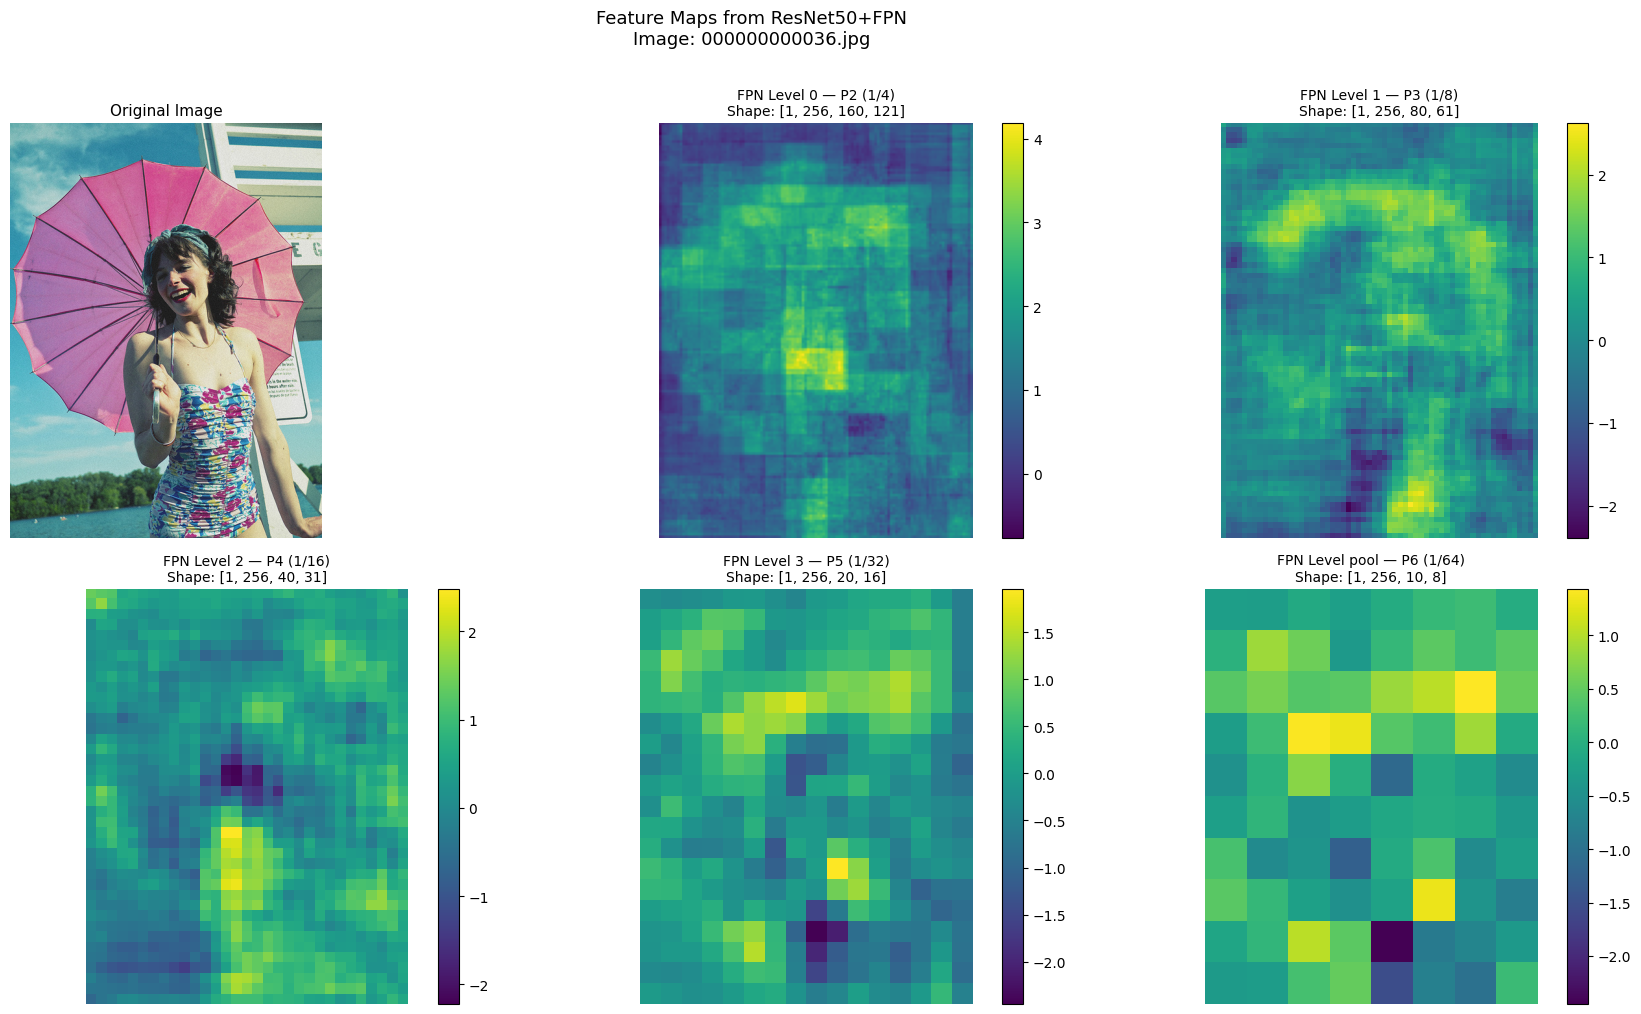

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Use a real image from your dataset for meaningful visualisation
import os
from PIL import Image
import torchvision.transforms.functional as F

# Load one real image
img_dir   = r"D:\Projects\ODM Project\People_vehicles dataset\filtered_images"
img_name  = os.listdir(img_dir)[0]
img_path  = os.path.join(img_dir, img_name)

img_pil   = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(img_pil).unsqueeze(0)   # [1, 3, H, W]

with torch.no_grad():
    features = backbone(img_tensor)

# Plot one channel from each FPN level
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Original image
axes[0].imshow(img_pil)
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis("off")

# Feature map from each FPN level (channel 0)
level_names = ["P2 (1/4)", "P3 (1/8)", "P4 (1/16)", "P5 (1/32)", "P6 (1/64)"]
for i, (key, fmap) in enumerate(features.items()):
    ax    = axes[i + 1]
    fm_np = fmap[0, 0].numpy()   # first image, first channel
    im    = ax.imshow(fm_np, cmap="viridis")
    ax.set_title(f"FPN Level {key} — {level_names[i]}\nShape: {list(fmap.shape)}", fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Feature Maps from ResNet50+FPN\nImage: {img_name}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Freeze early layers (stem + layer1) — recommended for fine-tuning
freeze_backbone_layers(backbone, freeze_until_layer=2)

# Print full summary
get_backbone_info(backbone)

# Show which layers are frozen vs trainable
print("=== Layer-by-layer Freeze Status ===\n")
for name, param in backbone.named_parameters():
    status = "FROZEN    " if not param.requires_grad else "trainable"
    # Only print first occurrence of each major layer
    if any(x in name for x in ["conv1", "layer1.0", "layer2.0", "layer3.0",
                                 "layer4.0", "fpn"]):
        print(f"  {status} | {name}")

[Backbone] Frozen params: 24 | Trainable params: 45

=== Backbone Summary ===
  Output channels : 256
  Total params    : 26,799,296
  Frozen params   : 1,434,816
  Trainable params: 25,364,480

=== Layer-by-layer Freeze Status ===

  FROZEN     | body.conv1.weight
  FROZEN     | body.layer1.0.conv1.weight
  FROZEN     | body.layer1.0.conv2.weight
  FROZEN     | body.layer1.0.conv3.weight
  FROZEN     | body.layer1.0.downsample.0.weight
  FROZEN     | body.layer1.1.conv1.weight
  FROZEN     | body.layer1.2.conv1.weight
  FROZEN     | body.layer2.0.conv1.weight
  FROZEN     | body.layer2.0.conv2.weight
  FROZEN     | body.layer2.0.conv3.weight
  FROZEN     | body.layer2.0.downsample.0.weight
  FROZEN     | body.layer2.1.conv1.weight
  FROZEN     | body.layer2.2.conv1.weight
  FROZEN     | body.layer2.3.conv1.weight
  trainable | body.layer3.0.conv1.weight
  trainable | body.layer3.0.conv2.weight
  trainable | body.layer3.0.conv3.weight
  trainable | body.layer3.0.downsample.0.weight
  t

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Move backbone to GPU
backbone = backbone.to(device)
dummy    = torch.rand(2, 3, 800, 800).to(device)

with torch.no_grad():
    features_gpu = backbone(dummy)

print(f"\nForward pass on {device} successful!")
print(f"Feature device: {list(features_gpu.values())[0].device}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB

Forward pass on cuda successful!
Feature device: cuda:0


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Run forward pass on whatever device is available
backbone = backbone.to(device)
dummy    = torch.rand(2, 3, 800, 800).to(device)

with torch.no_grad():
    features = backbone(dummy)

checks = {
    "Backbone builds without error"   : backbone is not None,
    "FPN outputs 5 levels"            : len(features) == 5,
    "All levels have 256 channels"    : all(f.shape[1] == 256 for f in features.values()),
    "Running on best available device": list(features.values())[0].device.type == device.type,
    "Frozen params exist"             : any(not p.requires_grad for p in backbone.parameters()),
    "Trainable params exist"          : any(p.requires_grad for p in backbone.parameters()),
}

print("=== Step 2 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for Step 3 (Detection Head)!")
else:
    print("Fix the failing checks before moving on.")

=== Step 2 Checklist ===

  ✅  Backbone builds without error
  ✅  FPN outputs 5 levels
  ✅  All levels have 256 channels
  ✅  Running on best available device
  ✅  Frozen params exist
  ✅  Trainable params exist

All checks passed — ready for Step 3 (Detection Head)!
